# 06. Lorenz-63 AI Surrogate Model

이 노트북에서는 신경망으로 Lorenz-63 **surrogate model(대체 모델)** 을 학습한다.

지금까지는 물리 방정식(Lorenz-63 RHS)을 직접 적분했다.
여기서는 그 방정식을 모른다고 가정하고, **데이터만 보고** 다음 상태를 예측하는
신경망을 학습한다. 이런 모델을 surrogate(대체) 또는 emulator라고 한다.

핵심 아이디어는 "한 step 사상(map)"을 학습하는 것이다.

$$
\mathbf{x}_{n+1} = \mathcal{M}(\mathbf{x}_n) \quad\Rightarrow\quad
\text{신경망 } \mathcal{M}_\theta \text{ 로 근사}
$$

이번 실습에서는 외부 딥러닝 라이브러리 없이, `lorenz_da.ai`에 numpy로 직접 구현한
MLP를 사용한다. 학습 목표는 다음과 같다.

1. 수치모델 trajectory로 학습 데이터를 만든다.
2. 증분(increment)을 예측하는 MLP를 학습한다.
3. 한 step 예측 정확도를 확인한다.
4. 여러 step을 이어 붙인 rollout에서 오차가 어떻게 누적되는지 본다.
5. surrogate가 attractor를 재현하는지 확인한다.

## 1. 라이브러리 불러오기

In [1]:
import sys
from pathlib import Path

# --- bootstrap: 프로젝트 루트의 src/ 를 sys.path 에 추가해 lorenz_da import 를 보장한다 ---
#     editable 설치 위치에 의존하지 않으므로, 프로젝트를 다른 경로로 옮겨도 동작한다.
_p = Path.cwd().resolve()
for _d in (_p, *_p.parents):
    if (_d / "pyproject.toml").exists() or (_d / ".git").exists():
        if str(_d / "src") not in sys.path:
            sys.path.insert(0, str(_d / "src"))
        break

import numpy as np
import matplotlib.pyplot as plt

from lorenz_da.models.lorenz63 import lorenz63_rhs, lorenz63_default_initial_condition
from lorenz_da.numerics.euler import integrate_euler
from lorenz_da.ai.dataset import make_increment_dataset, Standardizer
from lorenz_da.ai.models import MLP
from lorenz_da.ai.train import train, surrogate_step, surrogate_rollout
from lorenz_da.utils.diagnostics import rmse_time_series

from lorenz_da.utils.io import find_project_root, get_output_dirs

## 2. 프로젝트 경로 설정

In [2]:
PROJECT_ROOT = find_project_root()
paths = get_output_dirs(PROJECT_ROOT)
FIGURE_DIR = paths["figures"]
TRAJECTORY_DIR = paths["trajectories"]
ASSIM_DIR = paths["assimilation"]
CKPT_DIR = paths["checkpoints"]

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/sanggyu/projects/lorenz-da-lab
Figure directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures


## 3. 학습 데이터 만들기

Lorenz-63 모델을 길게 적분해 trajectory를 만들고, 앞부분을 학습용,
뒷부분을 평가용으로 나눈다.

신경망은 절대 상태값 $\mathbf{x}_{n+1}$ 대신 **증분** $\Delta\mathbf{x} = \mathbf{x}_{n+1} - \mathbf{x}_n$ 을
예측하도록 둔다. 증분은 값이 작아 학습이 더 안정적이다.

또한 입력과 출력을 각각 표준화(평균 0, 표준편차 1)한다.

In [3]:
dt = 0.01
seed = 42

x0 = lorenz63_default_initial_condition()
traj = integrate_euler(x0, dt=dt, nsteps=8000, rhs_func=lorenz63_rhs)

# 학습/평가 분리
n_train = 6000
traj_train = traj[: n_train + 1]
traj_test = traj[n_train:]

X, dY = make_increment_dataset(traj_train)
in_scaler = Standardizer().fit(X)
out_scaler = Standardizer().fit(dY)
Xs = in_scaler.transform(X)
dYs = out_scaler.transform(dY)

print("학습 입력 X shape:", Xs.shape)
print("학습 목표 dY shape:", dYs.shape)

학습 입력 X shape: (6000, 3)
학습 목표 dY shape: (6000, 3)


## 4. MLP 학습

은닉층이 2개($32 \times 32$)인 작은 MLP를 Adam optimizer로 학습한다.
은닉층 활성함수는 tanh, 출력은 선형이다.

In [4]:
rng = np.random.default_rng(seed)
mlp = MLP([3, 32, 32, 3], rng=rng)

history = train(mlp, Xs, dYs, epochs=1500, lr=5e-3, batch_size=128, rng=rng)

print("초기 loss:", history[0])
print("최종 loss:", history[-1])

초기 loss: 0.2742945457679124
최종 loss: 7.976274169004814e-05


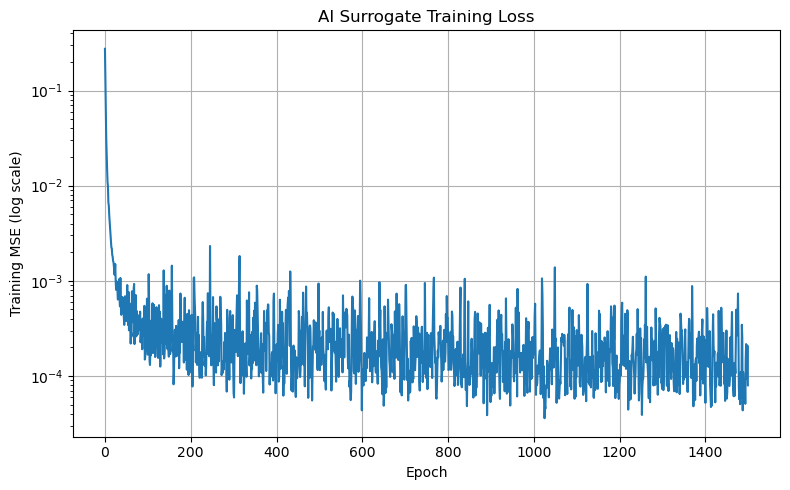

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/06_ai_training_loss.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(history)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training MSE (log scale)")
ax.set_title("AI Surrogate Training Loss")
ax.grid(True)
fig.tight_layout()
fig_path = FIGURE_DIR / "06_ai_training_loss.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 5. 한 step 예측 정확도 (평가 데이터)

학습에 쓰지 않은 평가 구간에서, 각 상태에 대해 한 step 예측을 수행하고
실제 다음 상태와의 오차를 본다. surrogate가 사상 $\mathcal{M}$ 을 잘 배웠다면 오차가 작아야 한다.

한 step 예측 오차 (평가 구간)
  평균 : 0.010870949647073868
  최대 : 0.17357926254450082


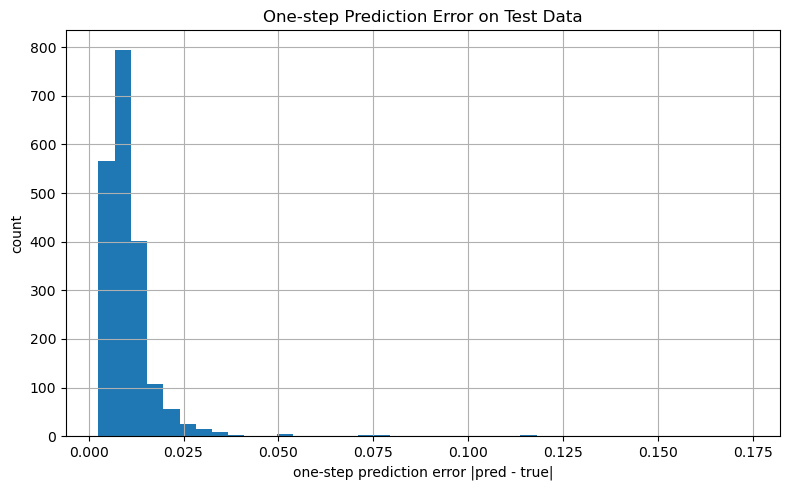

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/06_ai_one_step_error.png


In [6]:
X_test = traj_test[:-1]
Y_test = traj_test[1:]

pred_next = np.array([surrogate_step(mlp, x, in_scaler, out_scaler) for x in X_test])
step_errors = np.linalg.norm(pred_next - Y_test, axis=1)

print("한 step 예측 오차 (평가 구간)")
print("  평균 :", step_errors.mean())
print("  최대 :", step_errors.max())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(step_errors, bins=40)
ax.set_xlabel("one-step prediction error |pred - true|")
ax.set_ylabel("count")
ax.set_title("One-step Prediction Error on Test Data")
ax.grid(True)
fig.tight_layout()
fig_path = FIGURE_DIR / "06_ai_one_step_error.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 6. 다중 step 예측 (rollout)

이제 surrogate를 **반복 적용**한다. 예측 결과를 다시 입력으로 넣어 여러 step을 이어 간다.
한 step 오차가 작아도, 반복하면 오차가 누적되고 Lorenz-63의 chaotic한 성질 때문에
결국 참값과 갈라진다.

같은 초기조건에서 출발한 **진짜 수치모델(Euler)** 궤적과 비교한다.

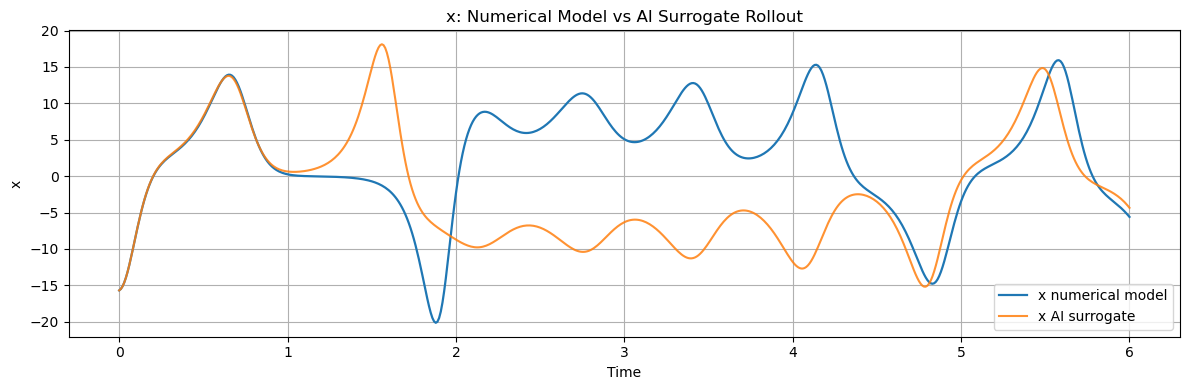

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/06_ai_rollout_x.png


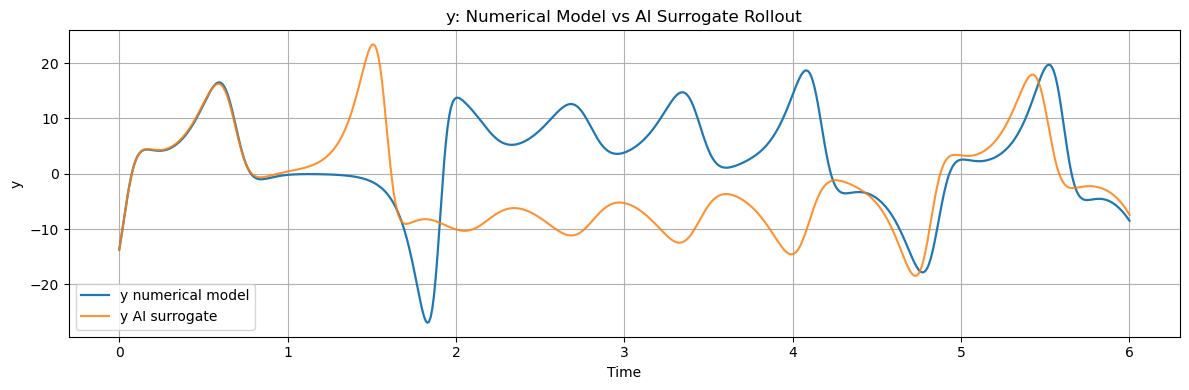

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/06_ai_rollout_y.png


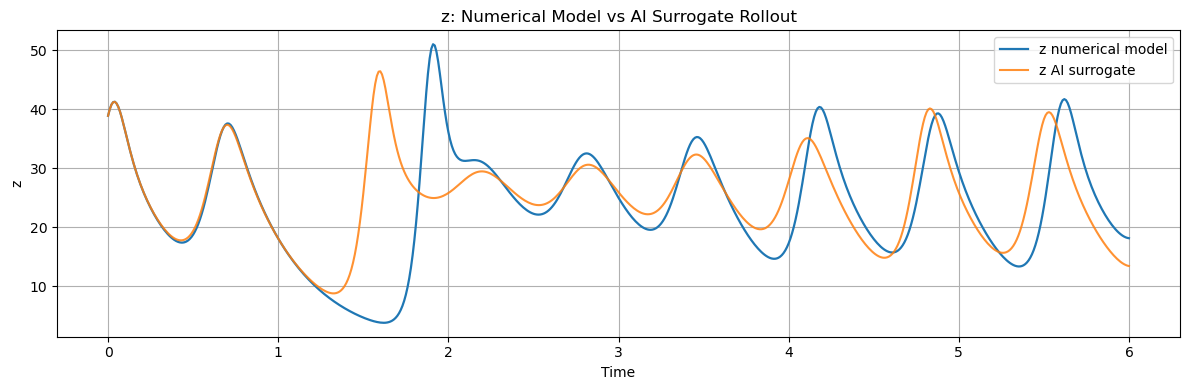

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/06_ai_rollout_z.png


In [7]:
x0_roll = traj_test[0]
n_roll = 600

true_roll = integrate_euler(x0_roll, dt=dt, nsteps=n_roll, rhs_func=lorenz63_rhs)
ai_roll = surrogate_rollout(mlp, x0_roll, n_roll, in_scaler, out_scaler)
t_roll = np.arange(n_roll + 1) * dt

var_names = ["x", "y", "z"]
for i, name in enumerate(var_names):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t_roll, true_roll[:, i], label=f"{name} numerical model", linewidth=1.6)
    ax.plot(t_roll, ai_roll[:, i], label=f"{name} AI surrogate", alpha=0.85)
    ax.set_xlabel("Time"); ax.set_ylabel(name)
    ax.set_title(f"{name}: Numerical Model vs AI Surrogate Rollout")
    ax.legend(); ax.grid(True)
    fig.tight_layout()
    fig_path = FIGURE_DIR / f"06_ai_rollout_{name}.png"
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print("Saved figure:", fig_path)

## 7. 오차 누적과 attractor 재현

왼쪽: rollout RMSE가 시간에 따라 어떻게 커지는지.
오른쪽: 그래도 surrogate 궤적이 Lorenz attractor "모양" 위에 머무는지.

핵심 관찰: 짧은 시간에는 surrogate가 참값을 잘 따라가지만, chaotic 시스템이라
오차가 지수적으로 커져 결국 위상이 어긋난다. 그러나 잘 학습된 surrogate는
참값과 점 대 점으로는 갈라져도 **attractor의 통계적 구조(기후)** 는 재현한다.

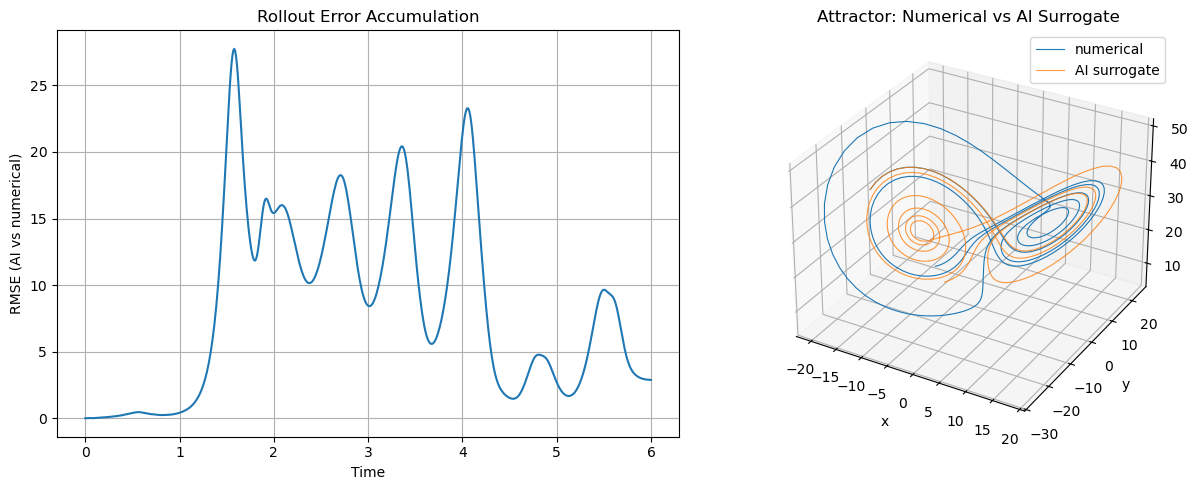

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/06_ai_rollout_error_and_attractor.png


In [8]:
roll_rmse = rmse_time_series(ai_roll, true_roll)

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t_roll, roll_rmse)
ax1.set_xlabel("Time"); ax1.set_ylabel("RMSE (AI vs numerical)")
ax1.set_title("Rollout Error Accumulation")
ax1.grid(True)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(true_roll[:, 0], true_roll[:, 1], true_roll[:, 2],
         label="numerical", linewidth=0.8)
ax2.plot(ai_roll[:, 0], ai_roll[:, 1], ai_roll[:, 2],
         label="AI surrogate", linewidth=0.8, alpha=0.8)
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
ax2.set_title("Attractor: Numerical vs AI Surrogate")
ax2.legend()

fig.tight_layout()
fig_path = FIGURE_DIR / "06_ai_rollout_error_and_attractor.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 8. 결과 저장

In [9]:
np.savez(
    CKPT_DIR / "06_ai_surrogate.npz",
    **{f"W{i}": W for i, (W, b) in enumerate(mlp.params)},
    **{f"b{i}": b for i, (W, b) in enumerate(mlp.params)},
    in_mean=in_scaler.mean, in_std=in_scaler.std,
    out_mean=out_scaler.mean, out_std=out_scaler.std,
)

with open(CKPT_DIR / "06_ai_summary.txt", "w", encoding="utf-8") as f:
    f.write("Lorenz-63 AI surrogate 실습 요약\n\n")
    f.write(f"dt: {dt}, 학습 표본 수: {Xs.shape[0]}\n")
    f.write("network: MLP [3, 32, 32, 3], tanh, Adam\n\n")
    f.write(f"초기 loss: {history[0]:.6e}\n")
    f.write(f"최종 loss: {history[-1]:.6e}\n")
    f.write(f"한 step 예측 평균 오차(평가): {step_errors.mean():.6e}\n")
print("Saved AI surrogate to:", CKPT_DIR)

Saved AI surrogate to: /Users/sanggyu/projects/lorenz-da-lab/outputs/checkpoints


## 9. 이번 실습 정리

이번 노트북에서는 Lorenz-63의 한 step 사상을 신경망으로 학습했다.

확인한 내용은 다음과 같다.

1. 수치모델 trajectory만으로, 방정식을 직접 쓰지 않고 다음 상태를 예측하는 surrogate를 학습할 수 있다.
2. 증분 예측 + 표준화가 학습을 안정적으로 만든다.
3. 한 step 예측은 매우 정확하다.
4. 그러나 rollout(반복 예측)에서는 오차가 누적되고, chaotic 시스템 특성상 결국 참값과 갈라진다.
5. 그래도 잘 학습된 surrogate는 attractor의 모양(기후)을 재현한다.

이런 surrogate는 (a) 빠른 예측 emulator, (b) 수치모델 오차를 보정하는 hybrid model,
(c) 자료동화에서 값싼 forward model 등으로 확장할 수 있다.

이로써 Lorenz DA Lab의 6개 핵심 주제(forward, 3D-Var, TLM, adjoint, 4D-Var, AI)와
앙상블 계열(EnKF, EnOI)이 모두 마무리된다.

In [10]:
print("여섯 번째 실습 완료")

여섯 번째 실습 완료
